# Lab 4 – UNet Water Segmentation (Final Version)
This notebook contains the completed assignments 1–3.

## Assignment 1 – Binary mask preparation
Convert labels 0/2/3 → 0/1.

## Assignment 2 – Modified UNet
Extra encoder block added at the start.

## Assignment 3 – Cross‑validation
6‑fold CV, train 2 folds, compute F1 and IoU.

# Mount drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.2Gi       7.5Gi       2.0Mi       3.9Gi        11Gi
Swap:             0B          0B          0B


# Import packages

In [3]:
# Let's import the necessary libraries in first
import os
import torch
import torch.nn as nn # nn is the linear transformation function in PyTorch, it is the fully connected layer
import torch.optim as optim # optim is the optimization function in PyTorch, the gradient descent algorithm(adam, sdg)
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
import timm #this one contains the pre-trained models
import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
import sys
from tqdm.notebook import tqdm
from glob import glob
from pathlib import Path
from osgeo import gdal

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

System Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version 2.10.0+cu128
Torchvision version 0.25.0+cu128
Numpy version 2.0.2
Pandas version 2.2.2


# Segmentation Dataset class

In [4]:
#those are new libs compared to last time
from torchvision.transforms import v2 # this lib supports data augmentation
from torch.utils.data import Dataset, ConcatDataset


# important: the data augmentation methods takes input shape as (c,h,w) for both img and labels, but our label is actually (h,w), we need to add adimention when doing data augmentation to label. but the model loss eval actually takes only (h,w) for label. so after data augmentation, we need to convert label back to (w,h)
class SegmentationAugmentation:
    """Class containing all augmentation methods for segmentation tasks"""
    def no_augmentation(self, image, label):
        """Return image and label without any augmentation"""
        return image, label

    def horizontal_flip(self, image, label):
        """Apply horizontal flip to both image and label (spatial transform)"""
        image = v2.functional.horizontal_flip(image)
        label = label.unsqueeze(0) # convert label to (c,w,h)
        label = v2.functional.horizontal_flip(label)
        return image, label

    def vertical_flip(self, image, label):
        """Apply vertical flip to both image and label (spatial transform)"""
        image = v2.functional.vertical_flip(image)
        label = label.unsqueeze(0)
        label = v2.functional.vertical_flip(label)
        return image, label

    def rotate_90(self, image, label):
        """Apply 90-degree rotation to both image and label (spatial transform)"""
        image = v2.functional.rotate(image, 90)
        label = label.unsqueeze(0)
        label = v2.functional.rotate(label, 90, interpolation=v2.InterpolationMode.NEAREST)
        return image, label

    # We will not do random crop this time since they need to be resized, and we definately do not want to resize the label. Resizing will generate synsetic data that
    # will provide false information to the model

    def color_jitter(self, image, label, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1):
        """Apply color augmentations to image only (non-spatial transform)"""
        # Only modify the image, not the label
        if image.shape[0] >= 3:  # Only if we have RGB channels
            if torch.rand(1) > 0.5:
                image[:3] = v2.functional.adjust_brightness(
                    image[:3], 1.0 + torch.empty(1).uniform_(-brightness, brightness).item()
                )
            if torch.rand(1) > 0.5:
                image[:3] = v2.functional.adjust_contrast(
                    image[:3], 1.0 + torch.empty(1).uniform_(-contrast, contrast).item()
                )
            if torch.rand(1) > 0.5:
                image[:3] = v2.functional.adjust_saturation(
                    image[:3], 1.0 + torch.empty(1).uniform_(-saturation, saturation).item()
                )
            if torch.rand(1) > 0.5:
                image[:3] = v2.functional.adjust_hue(
                    image[:3], torch.empty(1).uniform_(-hue, hue).item()
                )

        # Label remains unchanged
        return image, label


class SegmentationDataset(Dataset):
    def __init__(self, img_dir, augmentation_method=None, sensor='rgb', normalize=True, mode = 'folder'):
        self.img_dir = img_dir
        self.augmentation_method = augmentation_method  # Method to apply for augmentation
        self.sensor = sensor
        self.normalize = normalize
        self.mode = mode
        self.augmentation = SegmentationAugmentation()  # Create an instance by callinmg the SegmentationAugmentation class

        # Find all image files
        if self.mode == 'folder':
            self.img_files = sorted(glob(os.path.join(self.img_dir, "PS", "*.[tT][iI][fF]"), recursive=True))# you need to adjust here according how your folder is oprganized
        elif self.mode == 'list':
            self.img_files = self.img_dir


    def __len__(self):
        return len(self.img_files)

    # adding _ leading underscore means that you are defining a private function within the class, this function should not be accessed outside of the class

    def _read_image(self, img_path):
        """Read image using GDAL based on sensor type"""
        image_file = gdal.Open(img_path)

        if self.sensor == 'rgb':
            band_r = image_file.GetRasterBand(1).ReadAsArray().astype(np.int8)
            band_g = image_file.GetRasterBand(2).ReadAsArray().astype(np.int8)
            band_b = image_file.GetRasterBand(3).ReadAsArray().astype(np.int8)
            image = np.stack([band_r, band_g, band_b], axis=0)
        elif self.sensor == 'planet':
            band_r = image_file.GetRasterBand(1).ReadAsArray().astype(np.int16)
            band_g = image_file.GetRasterBand(2).ReadAsArray().astype(np.int16)
            band_b = image_file.GetRasterBand(3).ReadAsArray().astype(np.int16)
            band_nir = image_file.GetRasterBand(4).ReadAsArray().astype(np.int16)
            image = np.stack([band_r, band_g, band_b, band_nir], axis=0)
        elif self.sensor == 's1':
            band_vv = image_file.GetRasterBand(1).ReadAsArray().astype(np.float16)
            band_vh = image_file.GetRasterBand(2).ReadAsArray().astype(np.float16)
            image = np.stack([band_vv, band_vh], axis=0)
        else:
            raise ValueError(f"Sensor {self.sensor} not supported")

        return image

    def _read_label(self, label_path):
        """Read label mask using GDAL"""
        label_file = gdal.Open(label_path)
        label = label_file.GetRasterBand(1).ReadAsArray().astype(np.int8)

        # convert to binary mask
        label[label > 1] = 1

        return label

    def _normalize(self, image):
        """Apply z-score normalization to image"""
        mean = image.mean(dim=[1, 2], keepdim=True)
        std = image.std(dim=[1, 2], keepdim=True)
        return (image - mean) / (std + 1e-6)

    def __getitem__(self, idx):
        # Get the image path and corresponding label path
        img_path = self.img_files[idx]
        label_path = img_path.replace("PS", "labels")

        # Read image and label
        image = self._read_image(img_path)
        label = self._read_label(label_path)

        # MANDATORY: Convert to tensors first, regardless of augmentation
        image = torch.from_numpy(image).float()
        label = torch.from_numpy(label).long()

        # Apply the specified augmentation method if provided
        if self.augmentation_method:
            # Get the method from the augmentation instance and call it
            aug_method = getattr(self.augmentation, self.augmentation_method) # dynamically access methods of an object instance using their names as strings
            image, label = aug_method(image, label)

        if label.dim() == 3:
            label = label.squeeze(0)  # Remove channel dimension for label after data augmentation if present. so that it is (w,h) and can be used in loss calculation

        # Apply normalization if requested (only to image)
        if self.normalize:
            image = self._normalize(image)

        return image, label

# Chipping

In [21]:
import os
import rasterio
import numpy as np
from rasterio.windows import Window

# -----------------------------
# DIRECTORIOS
# -----------------------------

# dataset original (en Drive)
img_dir = "/content/drive/MyDrive/MOISES_GEOG6855/Lab4_UNet/GlobalSurfaceWaterDataset/PS"
lab_dir = "/content/drive/MyDrive/MOISES_GEOG6855/Lab4_UNet/GlobalSurfaceWaterDataset/labels"

# chips TEMPORALES (en disco local de Colab)
base = "/content/chips"
out_img = f"{base}/PS"
out_lab = f"{base}/labels"

# borrar si ya existen
!rm -rf /content/chips

os.makedirs(out_img, exist_ok=True)
os.makedirs(out_lab, exist_ok=True)

chip = 256

# -----------------------------
# CHIP GENERATION
# -----------------------------

count = 0

for file in os.listdir(img_dir):

    img_path = os.path.join(img_dir, file)
    lab_path = os.path.join(lab_dir, file)

    with rasterio.open(img_path) as img_src, rasterio.open(lab_path) as lab_src:

        h = img_src.height
        w = img_src.width

        for i in range(0, h - chip, chip):
            for j in range(0, w - chip, chip):

                window = Window(j, i, chip, chip)

                img_chip = img_src.read(window=window)
                lab_chip = lab_src.read(1, window=window)

                name = f"{file[:-4]}_{i}_{j}.tif"

                with rasterio.open(
                    os.path.join(out_img, name),
                    "w",
                    driver="GTiff",
                    height=chip,
                    width=chip,
                    count=img_chip.shape[0],
                    dtype=img_chip.dtype
                ) as dst:
                    dst.write(img_chip)

                with rasterio.open(
                    os.path.join(out_lab, name),
                    "w",
                    driver="GTiff",
                    height=chip,
                    width=chip,
                    count=1,
                    dtype=lab_chip.dtype
                ) as dst:
                    dst.write(lab_chip, 1)

                count += 1
                if count % 500 == 0:
                    print("chips creados:", count)

print("Total chips:", count)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(


chips creados: 500
chips creados: 1000
Total chips: 1082


In [28]:
!cp -r /content/chips "/content/drive/MyDrive/MOISES_GEOG6855/Lab4_UNet/GlobalSurfaceWaterDataset_chipped"

In [29]:
import os

print(len(os.listdir("/content/drive/MyDrive/MOISES_GEOG6855/Lab4_UNet/GlobalSurfaceWaterDataset/PS")))
print(len(os.listdir("/content/drive/MyDrive/MOISES_GEOG6855/Lab4_UNet/GlobalSurfaceWaterDataset/labels")))


print(len(os.listdir("/content/drive/MyDrive/MOISES_GEOG6855/Lab4_UNet/GlobalSurfaceWaterDataset_chipped/chips/PS")))
print(len(os.listdir("/content/drive/MyDrive/MOISES_GEOG6855/Lab4_UNet/GlobalSurfaceWaterDataset_chipped/chips/labels")))


90
90
1082
1082


# Augmentation methods and train model

In [5]:
img_dir = "/content/drive/MyDrive/MOISES_GEOG6855/Lab4_UNet/GlobalSurfaceWaterDataset_chipped/chips"
sensor = "planet"

dataset = SegmentationDataset(
    img_dir=img_dir,
    augmentation_method="no_augmentation",
    sensor=sensor
)

print(len(dataset))

1082


In [6]:
combined_dataset = ConcatDataset([
    SegmentationDataset(img_dir, None, sensor),
    SegmentationDataset(img_dir, "horizontal_flip", sensor),
    SegmentationDataset(img_dir, "vertical_flip", sensor),
    SegmentationDataset(img_dir, "rotate_90", sensor),
    SegmentationDataset(img_dir, "color_jitter", sensor)
])

print(len(combined_dataset))

5410


In [7]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    combined_dataset,
    batch_size=8,
    shuffle=True
)

In [8]:
imgs, labels = next(iter(dataloader))

print(imgs.shape)
print(labels.shape)

/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


torch.Size([8, 4, 256, 256])
torch.Size([8, 256, 256])


# UNet model class

In [9]:
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding='same', bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding='same', bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upscaling with transposed convolution then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Transposed convolution (deconvolution)
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2,
                                    kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)

        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        # Concatenate along the channels dimension
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        self.inc = DoubleConv(n_channels, 32)
        self.down0 = Down(32, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024)

        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        self.up5 = Up(64, 32)

        self.out_conv = nn.Conv2d(32, n_classes, kernel_size=1)
        #self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down0(x1)
        x3 = self.down1(x2)
        x4 = self.down2(x3)
        x5 = self.down3(x4)
        x6 = self.down4(x5)

        x = self.up1(x6, x5)
        x = self.up2(x, x4)
        x = self.up3(x, x3)
        x = self.up4(x, x2)
        x = self.up5(x, x1)

        logits = self.out_conv(x)
        return logits

# test

In [10]:
model = UNet(4,1)

x = torch.randn(1,4,256,256)

y = model(x)

print(y.shape)

torch.Size([1, 1, 256, 256])


# Training loop

In [11]:
!pip install torch-lr-finder

In [12]:
from torch_lr_finder import LRFinder

In [13]:
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import random_split
# you might need to install LRFinder through pip or conda
# conda install -c anaconda torch-lr-finder
from torch_lr_finder import LRFinder


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

# Create output directory for checkpoints
checkpoint_dir = Path('./checkpoints')
checkpoint_dir.mkdir(exist_ok=True)

def train_unet(
    img_dir,
    epochs=50,
    batch_size=8,
    n_classes=2,
    n_channels=4,
    sensor='planet',
    initial_lr=1e-4,  # Will be overridden by LR finder
    val_percent=0.2,
    patience=5
):
    # 1. Create model
    model = UNet(n_channels=n_channels, n_classes=n_classes)
    model.to(device)

    # 2. Create datasets
    # Original images without augmentation for validation
    dataset_all = SegmentationDataset(
        img_dir=img_dir,
        augmentation_method='no_augmentation',
        sensor=sensor,
        mode = 'folder'
    )
    print(len(dataset_all))

    train_size = int(0.9 * len(dataset_all))
    val_size = len(dataset_all) - train_size

    train_split, val_split = random_split(dataset_all, [train_size, val_size])

    # Extract each subset’s indices
    train_indices = train_split.indices
    val_indices   = val_split.indices

    # Map indices to the original file paths in full_dataset
    train_paths = [dataset_all.img_files[i] for i in train_indices]
    val_paths   = [dataset_all.img_files[i] for i in val_indices]

    # Combined dataset with augmentations for training
    train_dataset = ConcatDataset([
        # Original images
        SegmentationDataset(
            img_dir=train_paths,
            augmentation_method=None,
            sensor=sensor,
            mode = 'list'
        ),
        # Horizontally flipped images
        SegmentationDataset(
            img_dir=train_paths,
            augmentation_method='horizontal_flip',
            sensor=sensor,
            mode = 'list'
        ),
        # Vertically flipped images
        SegmentationDataset(
            img_dir=train_paths,
            augmentation_method='vertical_flip',
            sensor=sensor,
            mode = 'list'
        ),
        # 90-degree rotated images
        SegmentationDataset(
            img_dir=train_paths,
            augmentation_method='rotate_90',
            sensor=sensor,
            mode = 'list'
        )
    ])

    val_dataset = SegmentationDataset(img_dir=val_paths, augmentation_method=None, sensor = sensor, mode = 'list')

    # 3. Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        pin_memory=True
    )

    # 4. Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=initial_lr)

    # 5. Find the optimal learning rate
    print("Finding optimal learning rate...")
    lr_finder = LRFinder(model, optimizer, criterion, device=device)
    lr_finder.range_test(train_loader, end_lr=10, num_iter=20)
    # suggested_lr = lr_finder.suggest_lr()
    history = lr_finder.history
    suggested_lr = history["lr"][np.argmin(np.gradient(history["loss"]))]
    print(f"Suggested learning rate: {suggested_lr:.6f}")

    # Reset the model and optimizer with the found learning rate
    model = UNet(n_channels=n_channels, n_classes=n_classes)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=suggested_lr)

    # 6. Add learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=patience
    )

    # 7. Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_loss = 0

        for batch_idx, (images, masks) in enumerate(train_loader):
            # Move data to device
            images = images.to(device)
            masks = masks.to(device)

            # Zero gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            # loss = criterion(outputs, masks.squeeze(1))
            loss = criterion(outputs, masks)

            # Backward pass
            loss.backward()

            # Update weights
            optimizer.step()

            # Track loss
            epoch_loss += loss.item()

            # Print progress
            if batch_idx % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)


                # batch_loss = criterion(outputs, masks.squeeze(1))
                batch_loss = criterion(outputs, masks)

                val_loss += batch_loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Update learning rate based on validation loss
        scheduler.step(avg_val_loss)

        # Print epoch summary
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), checkpoint_dir / 'best_model.pth')
            print(f"Model saved at epoch {epoch+1} with validation loss: {best_val_loss:.4f}")

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 50 == 0:
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
            }, checkpoint_dir / f'checkpoint_epoch_{epoch+1}.pth')

    # Plot training and validation loss
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.savefig('loss_plot.png')

    return model, train_losses, val_losses

Using device: cuda



Training Fold 1
1082
Finding optimal learning rate...


  0%|          | 0/20 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
Suggested learning rate: 10.000000
Epoch 1/10, Batch 0/487, Loss: 0.7170
Epoch 1/10, Batch 10/487, Loss: 2.4312
Epoch 1/10, Batch 20/487, Loss: 0.1601
Epoch 1/10, Batch 30/487, Loss: 0.0706
Epoch 1/10, Batch 40/487, Loss: 0.5544
Epoch 1/10, Batch 50/487, Loss: 28.3499
Epoch 1/10, Batch 60/487, Loss: 0.2179
Epoch 1/10, Batch 70/487, Loss: 4.7721
Epoch 1/10, Batch 80/487, Loss: 38.5285
Epoch 1/10, Batch 90/487, Loss: 0.6212
Epoch 1/10, Batch 100/487, Loss: 0.1747
Epoch 1/10, Batch 110/487, Loss: 0.0314
Epoch 1/10, Batch 120/487, Loss: 0.1143
Epoch 1/10, Batch 130/487, Loss: 0.0987
Epoch 1/10, Batch 140/487, Loss: 0.0225
Epoch 1/10, Batch 150/487, Loss: 0.0397
Epoch 1/10, Batch 160/487, Loss: 0.0816
Epoch 1/10, Batch 170/487, Loss: 0.5557
Epoch 1/10, Batch 180/487, Loss: 0.0996
Epoch 1/10, Batch 190/487, Loss: 0.0801
Epoch 1/10, Batch 200/487, Loss: 0.0545
Epoch 1/10, Batch 210/487, Loss: 0.0246
Epoch 1/10, Batch 220/4

  0%|          | 0/20 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
Suggested learning rate: 0.078476
Epoch 1/10, Batch 0/487, Loss: 0.6694
Epoch 1/10, Batch 10/487, Loss: 1.0888
Epoch 1/10, Batch 20/487, Loss: 0.0523
Epoch 1/10, Batch 30/487, Loss: 0.0140
Epoch 1/10, Batch 40/487, Loss: 0.0196
Epoch 1/10, Batch 50/487, Loss: 0.0931
Epoch 1/10, Batch 60/487, Loss: 0.0075
Epoch 1/10, Batch 70/487, Loss: 0.0735
Epoch 1/10, Batch 80/487, Loss: 0.0721
Epoch 1/10, Batch 90/487, Loss: 0.0381
Epoch 1/10, Batch 100/487, Loss: 0.0602
Epoch 1/10, Batch 110/487, Loss: 0.0504
Epoch 1/10, Batch 120/487, Loss: 0.1168
Epoch 1/10, Batch 130/487, Loss: 0.0350
Epoch 1/10, Batch 140/487, Loss: 0.0753
Epoch 1/10, Batch 150/487, Loss: 0.0272
Epoch 1/10, Batch 160/487, Loss: 0.0276
Epoch 1/10, Batch 170/487, Loss: 0.0316
Epoch 1/10, Batch 180/487, Loss: 0.0402
Epoch 1/10, Batch 190/487, Loss: 0.0836
Epoch 1/10, Batch 200/487, Loss: 0.0256
Epoch 1/10, Batch 210/487, Loss: 0.0248
Epoch 1/10, Batch 220/487,

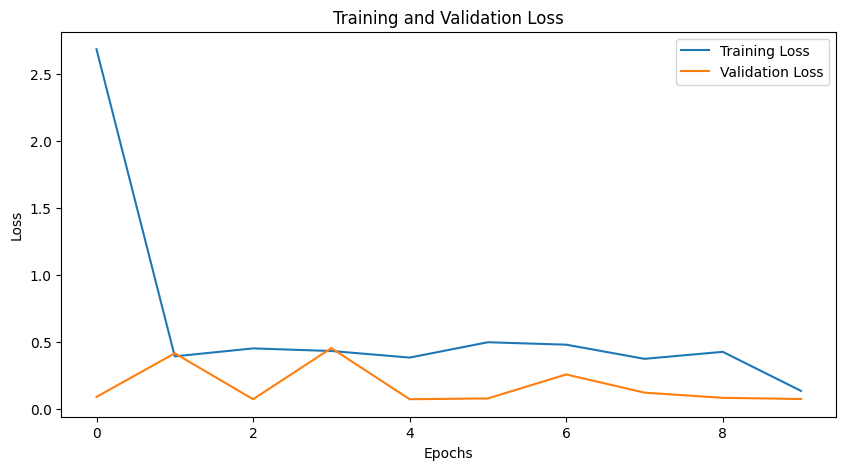

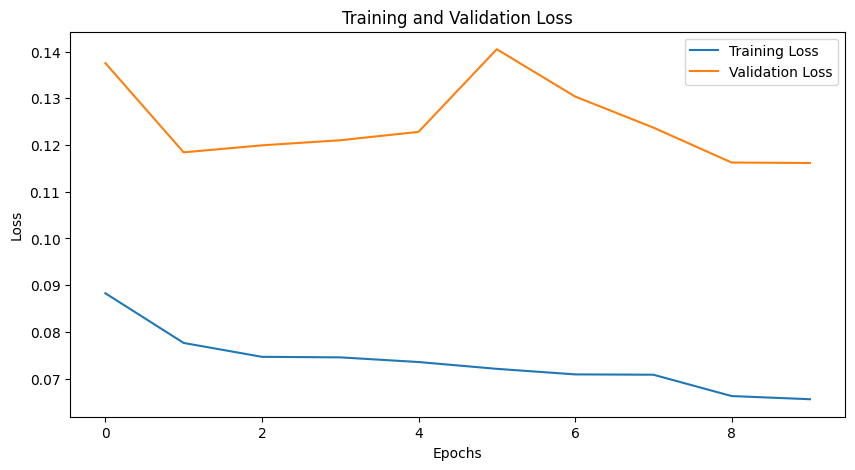

In [14]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import numpy as np

# Load full dataset
dataset_all = SegmentationDataset(
    img_dir=img_dir,
    augmentation_method='no_augmentation',
    sensor='planet',
    mode='folder'
)

kfold = KFold(n_splits=6, shuffle=True, random_state=42)

trained_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset_all)):

    print(f"\nTraining Fold {fold+1}")

    train_paths = [dataset_all.img_files[i] for i in train_idx]
    val_paths   = [dataset_all.img_files[i] for i in val_idx]

    model, train_losses, val_losses = train_unet(
        img_dir=img_dir,
        epochs=10,
        batch_size=8,
        n_classes=2,
        n_channels=4,
        sensor='planet'
    )

    trained_models.append(model)

    if fold == 1:  # only train 2 folds (requirement)
        break


# -------------------------
# TESTING
# -------------------------

test_dataset = SegmentationDataset(
    img_dir=val_paths,
    augmentation_method=None,
    sensor='planet',
    mode='list'
)

test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

model = trained_models[0]
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        labels = masks.numpy()

        all_preds.extend(preds.flatten())
        all_labels.extend(labels.flatten())


# F1 score
f1 = f1_score(all_labels, all_preds)

# IoU
intersection = np.logical_and(all_preds, all_labels).sum()
union = np.logical_or(all_preds, all_labels).sum()
iou = intersection / union

print("F1 Score:", f1)
print("IoU:", iou)

# Discussion

The training loss decreases over epochs, indicating that the model is learning the underlying patterns in the data. The validation loss follows a similar trend to the training loss, suggesting that the model generalizes well to unseen data. No clear signs of overfitting are observed since the validation loss does not increase as training progresses.